In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from astropy import units as u
import pandas as pd
# from dsph_analysis import kinematic_io
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
from dsph_analysis import kinematic_io

In [21]:
# catalog_path = '/home/jupyter-tvnguyen/datasets/mock_catalogs/icrs/mock_data/MockA.csv'
catalog_path = 'mock_data/MockB.csv'
meta = kinematic_io.load_meta('draco_1')
data = kinematic_io.load_kinematic_data(
    catalog_path,
    meta,
    source='mock_icrs',
    vlos_err_floor=0.0,
    apply_perspective_corr=True,
)

In [6]:
# np.log10(meta.rhalf_kpc.value)
print(meta.rhalf_kpc.value, 0.5 * (meta.rhalf_kpc_em + meta.rhalf_kpc_ep))


0.22924 0.004695 kpc


In [22]:
X_proj = data.X_proj.value
Y_proj = data.Y_proj.value
R_proj = data.R_proj.value
vlos = data.vlos.value
vlos_err = data.vlos_err.value

In [23]:
X_proj

array([-3.06058690e-01, -4.98760823e-02,  2.87491549e-01,  3.81075761e-02,
        4.61215954e-01, -2.96637453e-02,  9.98286591e-02,  3.30034569e-02,
       -1.14067639e-01,  4.24596040e-03,  5.20513031e-01, -8.34529901e-03,
       -6.28576267e-02, -7.30037719e-02,  7.18196445e-02, -3.12040382e-01,
       -2.37429147e-01, -1.15225169e-02, -1.17408165e-01,  1.43590933e-01,
        1.17769636e-01,  5.52888038e-01,  8.82475126e-01, -2.78361224e-02,
       -3.36867833e-01, -1.74210666e+00,  5.28291622e-01,  4.37958444e-02,
        7.40907171e-02, -1.93175755e-02, -1.80937114e-01,  4.72608536e-03,
        3.47337094e-01,  2.11767964e-01,  6.94966477e-01, -1.72945622e-02,
        8.98757145e-02, -1.17142670e-01, -5.66249625e-02,  5.70423739e-01,
        1.74652512e-01,  2.90562936e-01,  5.42155770e-02, -1.02485116e-01,
        1.09390500e-02, -2.85833750e-01,  4.18303235e-01, -9.57522316e-02,
       -2.68595214e-01,  3.19141213e-01, -1.99871217e-01, -4.72598182e-01,
        8.37391031e-02, -

In [5]:
np.testing.assert_almost_equal(R_proj, np.sqrt(X_proj**2 + Y_proj**2))

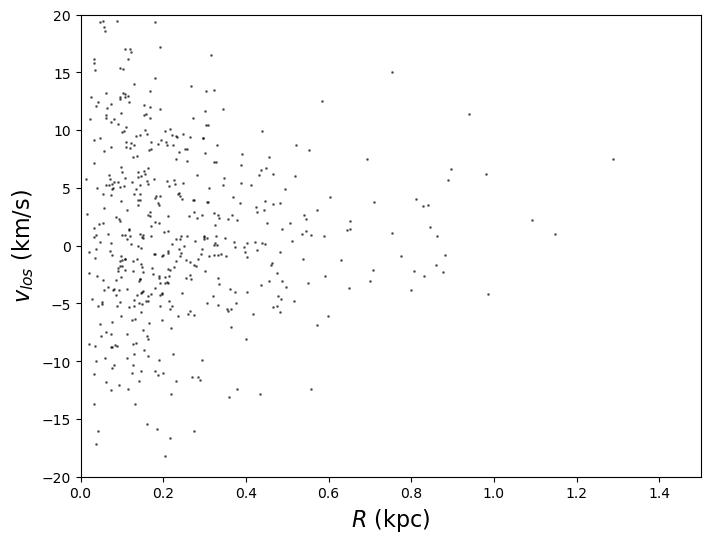

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(R_proj, vlos, s=1, color='k', alpha=0.5)
ax.set_xlim(0, 1.5)
ax.set_ylim(-20, 20)
ax.set_xlabel(r"$R$ (kpc)", fontsize=16)
ax.set_ylabel(r"$v_{los}$ (km/s)", fontsize=16)
# cbar.set_label("Number density", fontsize=16)
plt.show()

# Generate

In [7]:

mock = "D"
catalog_path = f'./draco1_walker23_noSF_blind/Mock{mock}.csv'
meta = kinematic_io.load_meta('draco_1')
data = kinematic_io.load_kinematic_data(
    catalog_path,
    meta,
    source='mock_icrs',
    vlos_err_floor=0.0,
    apply_perspective_corr=True,
)
X_proj = data.X_proj.value
Y_proj = data.Y_proj.value
R_proj = data.R_proj.value
vlos = data.vlos.value
vlos_err = data.vlos_err.value

array = np.zeros((200, 3))
array[:, 0], array[:, 1], array[:, 2] = X_proj, Y_proj, vlos
 
array

pd.DataFrame(array).to_csv(f"./8d_theta/model_8/mock_noSF/data/Mock{mock}_refined.csv", header=None, index=None)
pd.DataFrame(vlos_err).to_csv(f"./8d_theta/model_8/mock_noSF/data/Mock{mock}_unc.csv", header=None, index=None)